In [1]:
import numpy as np
import time
import redshifts
import common as c
import copy
import healpy as hp
import config as conf
import estim
from estim import estimator
import importlib
import spectra
import matplotlib.pyplot as plt
from math import pi
import my_remote_spectra as rs
from classy import Class
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%load_ext autoreload
%autoreload 2

In [2]:
def plot_cross_section(fft3dmap):
    fig, _ = plt.subplots(3, 1,figsize=(6*1,4.5*3))
    
    ax1 = plt.subplot(3,1,1)
    fig.colorbar(ax1.imshow(fft3dmap[0,:,:], origin='lower'), ax=ax1)
    ax1.set_xlabel('y')
    ax1.set_ylabel('z')

    ax2 = plt.subplot(3,1,2)
    # ax2.imshow(psi_i[0,:,:].T)
    fig.colorbar(ax2.imshow(fft3dmap[:,0,:].T, origin='lower'), ax=ax2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('z')

    ax3 = plt.subplot(3,1,3)
    # ax3.imshow(psi_i[:,10,:])
    fig.colorbar(ax3.imshow(fft3dmap[:,:,0], origin='lower'), ax=ax3)
    ax3.set_xlabel('y')
    ax3.set_ylabel('x')

def RDF_recNoise(lmin, lmax, Cltaug, ClTT, Clgg):
    # all the input spectra should include noise
    ls = np.arange(lmax+1)
    ls = np.tile(ls[:, np.newaxis], (1, Cltaug.shape[-1]))
    
    return 1/np.sum((2*ls[lmin:,]+1)/(4*np.pi)*Cltaug[lmin:,]**2/(ClTT[lmin:,]*Clgg[lmin:,]), axis=0)

def RQF_E_recNoise(lmin, lmax, Cltaug, ClEE, Clgg):
    # all the input spectra should include noise
    ls = np.arange(lmax+1)
    ls = np.tile(ls[:, np.newaxis], (1, Cltaug.shape[-1]))
    
    return 1/np.sum(6/100*(2*ls[lmin:,]+1)/(4*np.pi)*Cltaug[lmin:,]**2/(ClEE[lmin:,]*Clgg[lmin:,]), axis=0)

In [3]:
data_lmax = 4000
lmax = 4000
ls = np.arange(lmax+1)

zb = redshifts.binning(conf_module = conf) 
estimator = estimator(data_lmax, conf)
beam = conf.beamArcmin_T*np.pi/180./60.
dT = conf.noiseTuKArcmin_T*np.pi/180./60./conf.T_CMB
TT_noise = estimator.CMB_noise(np.arange(estimator.data_lmax+1), beam, dT)
EE_noise = 2*TT_noise

estimator.set_theory_Cls(add_ksz = False, add_ml=False)

Default lss = 'g' . Modify with set_lss method.
Default N_fine_modes = 4. Modify with set_Nfine method.


In [4]:
params = {
    'A_s':conf.As*1e-9,
    'n_s': conf.ns,
    'h':conf.h,
    'omega_b':conf.ombh2,
    'omega_cdm':conf.omch2,
    'tau_reio':conf.tau,
    "output" : " tCl, pCl, lCl" ,
    "l_max_scalars" : data_lmax,
    "lensing": 'yes'
}

cosmo = Class()
cosmo.set(params)
cosmo.compute(level=['lensing'])
lensed_cls = cosmo.lensed_cl()
raw_cls = cosmo.raw_cl()

True

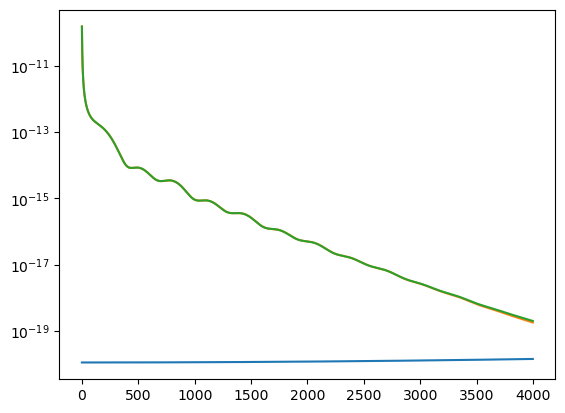

In [5]:
plt.plot(TT_noise[2:, 0, 0])
plt.plot(lensed_cls['tt'][2:])
plt.plot(estimator.Cls['pCMB-pCMB'][2:, 0, 0])
plt.yscale('log')

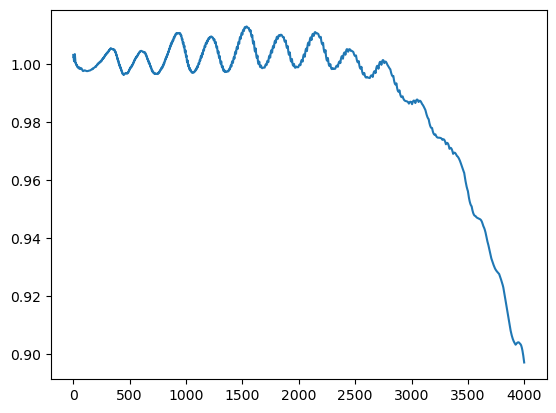

In [6]:
plt.plot(lensed_cls['tt'][2:data_lmax+1]/estimator.Cls['pCMB-pCMB'][2:, 0, 0])

In [7]:
Clgg = estimator.Cls['lss-lss'] # with shot noise (also maybe calibration noise)
Cltaudg = estimator.Cls['taud-lss']
Cltaug = Cltaudg*zb.deltachi
ClTT = estimator.Cls['T-T'] # with noise
ClEE = np.tile(lensed_cls['ee'][:, np.newaxis], (1, Cltaug.shape[-1]))
Clvrvr = estimator.Cls['vr-vr']
ClN_RDF = RDF_recNoise(2, lmax, Cltaug.diagonal(axis1=1, axis2=2), ClTT.diagonal(axis1=1, axis2=2), Clgg.diagonal(axis1=1, axis2=2))
ClN_RQF_E = RQF_E_recNoise(2, lmax, Cltaug.diagonal(axis1=1, axis2=2), ClTT.diagonal(axis1=1, axis2=2), Clgg.diagonal(axis1=1, axis2=2))

In [15]:
Clqeqe = rs.get_CLqq()

Calculating Cl_qq...
Done bin 0
Done bin 1
Done bin 2
Done bin 3


In [17]:
Clqeqe[]

(4, 100)

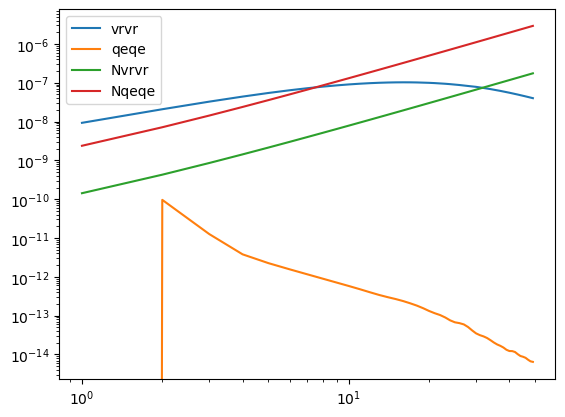

In [22]:
bin_num = 2
llow, lhigh = 1, 50

factor = (ls*(ls+1)/(2*pi))[llow:lhigh]

# plt.plot(L, CLgg[:, bin_num, bin_num], label='gg')
plt.plot(ls[llow:lhigh], factor*Clvrvr[:, bin_num, bin_num][llow:lhigh], label='vrvr')
plt.plot(ls[llow:lhigh], factor*Clqeqe[bin_num, :][llow:lhigh], label='qeqe')
plt.plot(ls[llow:lhigh], factor*(np.ones_like(ls)*ClN_RDF[bin_num])[llow:lhigh], label='Nvrvr')
plt.plot(ls[llow:lhigh], factor*(np.ones_like(ls)*ClN_RQF_E[bin_num])[llow:lhigh], label='Nqeqe')
plt.xscale('log')
plt.yscale('log')
plt.legend()

In [13]:
CLqq.shape

(4, 100)